# In the following script i used the following algorithms:
* **Random Forest Classifier**   Accuracy: **92.03%**
* **XGBoost**              Accuracy:  **90.03%**
* **Logistic Regression**   Accuracy: **96.5%**
* **SVC with GridSearch**     Accuracy: **97.25%**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mobile-price-classification/train.csv
/kaggle/input/mobile-price-classification/test.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt


train_data=pd.read_csv('/kaggle/input/mobile-price-classification/train.csv')
train_data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
train_data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [4]:
for i in train_data.columns:
    print(train_data[i].value_counts())

1872    6
618     6
1589    6
1715    5
1807    5
       ..
660     1
1452    1
1005    1
1372    1
858     1
Name: battery_power, Length: 1094, dtype: int64
0    1010
1     990
Name: blue, dtype: int64
0.5    413
2.8     85
2.3     78
2.1     76
1.6     76
2.5     74
0.6     74
1.4     70
1.3     68
1.5     67
2.0     67
1.9     65
0.7     64
2.9     62
1.8     62
1.0     61
1.7     60
2.2     59
0.9     58
2.4     58
0.8     58
1.2     56
2.6     55
2.7     55
1.1     51
3.0     28
Name: clock_speed, dtype: int64
1    1019
0     981
Name: dual_sim, dtype: int64
0     474
1     245
2     189
3     170
5     139
4     133
6     112
7     100
9      78
8      77
10     62
11     51
12     45
13     40
16     24
15     23
14     20
18     11
17      6
19      1
Name: fc, dtype: int64
1    1043
0     957
Name: four_g, dtype: int64
27    47
16    45
14    45
57    42
2     42
      ..
22    24
38    23
62    21
4     20
59    18
Name: int_memory, Length: 63, dtype: int64
0.1    320
0.2    

In [5]:
#After checking the value counts in the data i noticed that there were 180 sc_w(screen width) that were set to 0
#so i think removing the rows containing these values would be the best option
train_data['sc_w'].value_counts()

1     210
3     199
4     182
0     180
5     161
2     156
7     132
6     130
8     125
10    107
9      97
11     84
12     68
13     49
14     33
15     31
16     29
17     19
18      8
Name: sc_w, dtype: int64

In [6]:
train_data_f = train_data[train_data['sc_w'] != 0]
train_data_f.shape

(1820, 21)

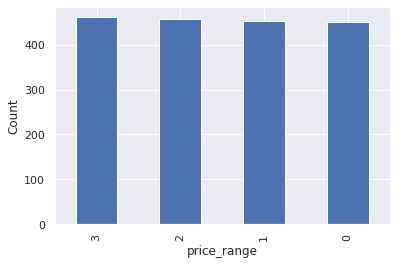

In [7]:
#The classes are balanced
sns.set()
price_plot=train_data_f['price_range'].value_counts().plot(kind='bar')
plt.xlabel('price_range')
plt.ylabel('Count')
plt.show()

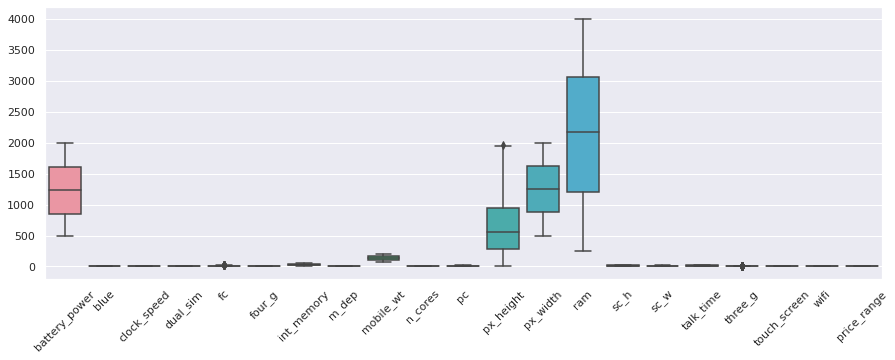

In [8]:
sns.set(rc={'figure.figsize':(15,5)})
ax=sns.boxplot(data=train_data_f)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
plt.show()

In [9]:
X=train_data_f.drop(['price_range'], axis=1)
y=train_data_f['price_range']

#There are no missing values
X.isna().any()

battery_power    False
blue             False
clock_speed      False
dual_sim         False
fc               False
four_g           False
int_memory       False
m_dep            False
mobile_wt        False
n_cores          False
pc               False
px_height        False
px_width         False
ram              False
sc_h             False
sc_w             False
talk_time        False
three_g          False
touch_screen     False
wifi             False
dtype: bool

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid= train_test_split(X, y, test_size=0.2, random_state=0)

In [11]:
#Funtion to build and visualise a confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
def my_confusion_matrix(y_test, y_pred, plt_title):
    cm=confusion_matrix(y_test, y_pred)
    print(classification_report(y_test, y_pred))
    sns.heatmap(cm, annot=True, fmt='g', cbar=False, cmap='BuPu')
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title(plt_title)
    plt.show()
    return cm

Random Forest Classifier Accuracy Score:  0.9203296703296703
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        91
           1       0.94      0.91      0.93       104
           2       0.83      0.92      0.87        77
           3       0.95      0.89      0.92        92

    accuracy                           0.92       364
   macro avg       0.92      0.92      0.92       364
weighted avg       0.92      0.92      0.92       364



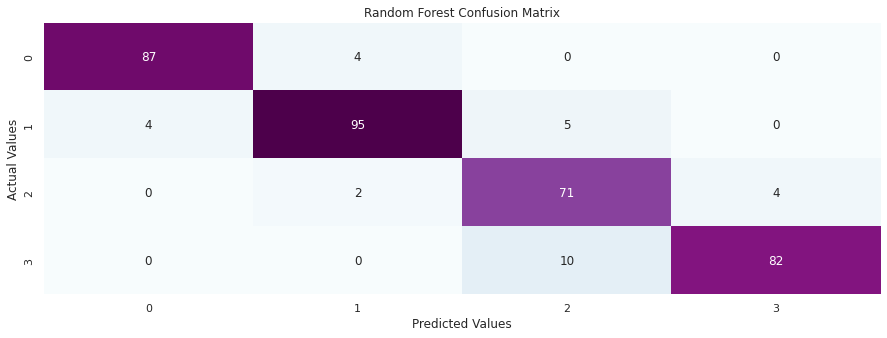

In [12]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(bootstrap= True,
                           max_depth= 80,
                           max_features= 15,
                           min_samples_leaf= 3,
                           min_samples_split= 10,
                           n_estimators= 100,
                           random_state=0)
rfc.fit(X_train, y_train)
y_pred_rfc=rfc.predict(X_valid)
print('Random Forest Classifier Accuracy Score: ',accuracy_score(y_valid,y_pred_rfc))
cm_rfc=my_confusion_matrix(y_valid, y_pred_rfc, 'Random Forest Confusion Matrix')

XGBoost Accuracy Score:  0.9038461538461539
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        91
           1       0.90      0.86      0.88       104
           2       0.82      0.87      0.84        77
           3       0.97      0.92      0.94        92

    accuracy                           0.90       364
   macro avg       0.90      0.90      0.90       364
weighted avg       0.91      0.90      0.90       364



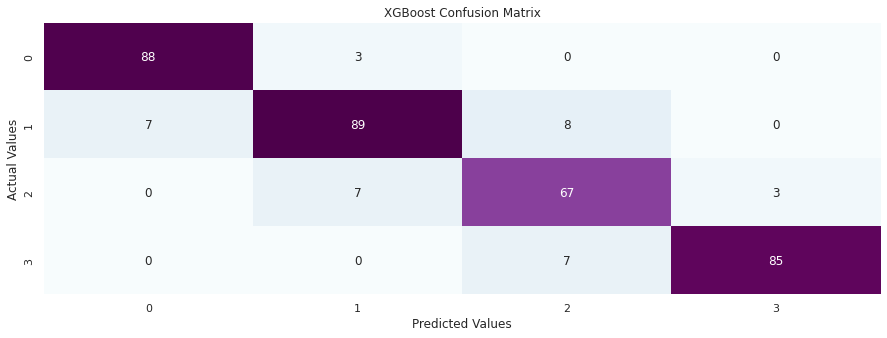

array([[88,  3,  0,  0],
       [ 7, 89,  8,  0],
       [ 0,  7, 67,  3],
       [ 0,  0,  7, 85]])

In [13]:
import xgboost as xgb
xgb_classifier=xgb.XGBClassifier(colsample_bytree= 0.6,
                                 eval_metric= 'logloss',
                                 gamma= 2,
                                 learning_rate= 0.1,
                                 max_depth= 5,
                                 min_child_weight= 1,
                                 subsample= 0.8,
                                 use_label_encoder=False,
                                 verbosity = 0,random_state=0)
xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_valid)
accuracy_score(y_valid,y_pred_xgb)
print('XGBoost Accuracy Score: ',accuracy_score(y_valid, y_pred_xgb))
my_confusion_matrix(y_valid, y_pred_xgb, 'XGBoost Confusion Matrix')

In [14]:
#Calculate the mutual information between the features and the target
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X_train, y_train, random_state=0)
mi

array([3.22523809e-02, 0.00000000e+00, 0.00000000e+00, 1.95040877e-02,
       0.00000000e+00, 7.98417228e-04, 3.50334976e-02, 0.00000000e+00,
       2.74888849e-02, 2.86202121e-02, 1.32783236e-02, 1.20678029e-04,
       2.90028523e-02, 8.33148967e-01, 0.00000000e+00, 3.28609198e-03,
       8.26935850e-03, 1.32228733e-02, 0.00000000e+00, 1.44758877e-03])

In [15]:
#indexing with col names
mi = pd.Series(mi)
mi.index = X_train.columns

mi.sort_values(ascending=False)

ram              0.833149
int_memory       0.035033
battery_power    0.032252
px_width         0.029003
n_cores          0.028620
mobile_wt        0.027489
dual_sim         0.019504
pc               0.013278
three_g          0.013223
talk_time        0.008269
sc_w             0.003286
wifi             0.001448
four_g           0.000798
px_height        0.000121
m_dep            0.000000
blue             0.000000
fc               0.000000
clock_speed      0.000000
sc_h             0.000000
touch_screen     0.000000
dtype: float64

In [16]:
#Creating a list containing feature names that has MI >0
selected_features=[]
for index, value in mi.items():
    if value>0:
        selected_features.append(index)
selected_features

['battery_power',
 'dual_sim',
 'four_g',
 'int_memory',
 'mobile_wt',
 'n_cores',
 'pc',
 'px_height',
 'px_width',
 'ram',
 'sc_w',
 'talk_time',
 'three_g',
 'wifi']

In [17]:
X_opt_train= X_train[selected_features]
X_opt_valid= X_valid[selected_features]

X_opt_train.head()

,battery_power,dual_sim,four_g,int_memory,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_w,talk_time,three_g,wifi
250,893,1,0,55,183,2,1,417,946,2986,1,6,0,1
965,1379,1,0,19,134,8,17,387,671,3912,2,19,0,1
588,1966,1,0,40,185,8,18,1197,1987,1185,2,20,0,0
1623,1862,0,0,62,182,1,2,386,1046,1017,3,9,1,0
1296,1644,0,1,44,137,8,0,358,791,2360,4,19,1,0


In [18]:
#Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_opt_train=pd.DataFrame(sc.fit_transform(X_opt_train))
X_opt_valid=pd.DataFrame(sc.transform(X_opt_valid))

X_opt_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.795881,0.994521,-1.044966,1.264736,1.196008,-1.096444,-1.469621,-0.507429,-0.697105,0.774673,-1.299361,-0.906797,-1.764368,0.959606
1,0.308665,0.994521,-1.044966,-0.720483,-0.193925,1.524939,1.184149,-0.575116,-1.331043,1.627820,-1.054776,1.480720,-1.764368,0.959606
2,1.642756,0.994521,-1.044966,0.437562,1.252739,1.524939,1.350010,1.252437,1.702637,-0.884633,-1.054776,1.664375,-1.764368,-1.042094
3,1.406393,-1.005510,-1.044966,1.650751,1.167642,-1.533341,-1.303760,-0.577372,-0.466582,-1.039416,-0.810190,-0.355832,0.566775,-1.042094
4,0.910938,-1.005510,0.956969,0.658142,-0.108827,1.524939,-1.635481,-0.640547,-1.054416,0.197923,-0.565604,1.480720,0.566775,-1.042094


In [19]:
#Scaling removed the indexes so i put them back
X_opt_train.columns=selected_features
X_opt_valid.columns=selected_features

X_opt_train.head()

,battery_power,dual_sim,four_g,int_memory,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_w,talk_time,three_g,wifi
0,-0.795881,0.994521,-1.044966,1.264736,1.196008,-1.096444,-1.469621,-0.507429,-0.697105,0.774673,-1.299361,-0.906797,-1.764368,0.959606
1,0.308665,0.994521,-1.044966,-0.720483,-0.193925,1.524939,1.184149,-0.575116,-1.331043,1.627820,-1.054776,1.480720,-1.764368,0.959606
2,1.642756,0.994521,-1.044966,0.437562,1.252739,1.524939,1.350010,1.252437,1.702637,-0.884633,-1.054776,1.664375,-1.764368,-1.042094
3,1.406393,-1.005510,-1.044966,1.650751,1.167642,-1.533341,-1.303760,-0.577372,-0.466582,-1.039416,-0.810190,-0.355832,0.566775,-1.042094
4,0.910938,-1.005510,0.956969,0.658142,-0.108827,1.524939,-1.635481,-0.640547,-1.054416,0.197923,-0.565604,1.480720,0.566775,-1.042094


Logistic Regresssion Accuracy Score:  0.967032967032967
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        91
           1       0.96      0.96      0.96       104
           2       0.93      0.97      0.95        77
           3       1.00      0.96      0.98        92

    accuracy                           0.97       364
   macro avg       0.97      0.97      0.97       364
weighted avg       0.97      0.97      0.97       364



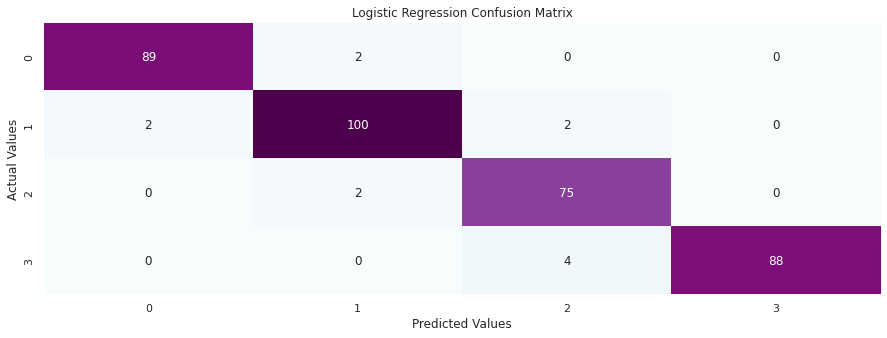

In [20]:
#Using Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(X_opt_train,y_train)
y_pred=classifier.predict(X_opt_valid)
print('Logistic Regresssion Accuracy Score: ',accuracy_score(y_valid,y_pred))
cm_rfc=my_confusion_matrix(y_valid, y_pred, 'Logistic Regression Confusion Matrix')

In [21]:
#Using Suppport vector Classifier with GridSearch
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC()
parameters = {'kernel':('linear', 'rbf'), 'C':[1, 10]}  #Parameters to try in GridSearch
svc_classifier = GridSearchCV(svc, parameters)
svc_classifier.fit(X_opt_train, y_train)
svc_classifier.best_params_

{'C': 10, 'kernel': 'linear'}

Support Vector Machine Accuracy Score:  0.9725274725274725
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        91
           1       0.97      0.98      0.98       104
           2       0.95      0.96      0.95        77
           3       0.98      0.97      0.97        92

    accuracy                           0.97       364
   macro avg       0.97      0.97      0.97       364
weighted avg       0.97      0.97      0.97       364



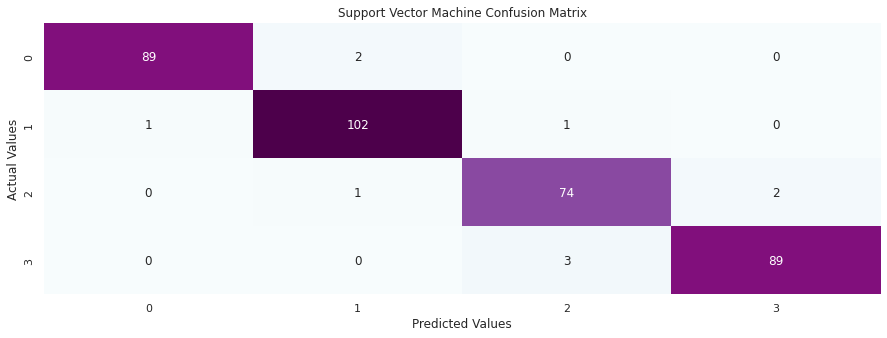

In [22]:
#Creating SVC model with the best params
svc = SVC(kernel='linear', C=10)
svc.fit(X_opt_train, y_train)
y_pred_svc= svc.predict(X_opt_valid)
print('Support Vector Machine Accuracy Score: ',accuracy_score(y_valid, y_pred_svc))
cm_svc=my_confusion_matrix(y_valid, y_pred_svc, 'Support Vector Machine Confusion Matrix')